In [6]:
import pandas as pd
import matplotlib.pyplot as plt

In [7]:
df = pd.read_csv('sales_data_sample.csv', encoding='latin1')

In [8]:
print("Dataset Ölçüsü:", df.shape)

Dataset Ölçüsü: (2823, 25)


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2823 entries, 0 to 2822
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ORDERNUMBER       2823 non-null   int64  
 1   QUANTITYORDERED   2823 non-null   int64  
 2   PRICEEACH         2823 non-null   float64
 3   ORDERLINENUMBER   2823 non-null   int64  
 4   SALES             2823 non-null   float64
 5   ORDERDATE         2823 non-null   object 
 6   STATUS            2823 non-null   object 
 7   QTR_ID            2823 non-null   int64  
 8   MONTH_ID          2823 non-null   int64  
 9   YEAR_ID           2823 non-null   int64  
 10  PRODUCTLINE       2823 non-null   object 
 11  MSRP              2823 non-null   int64  
 12  PRODUCTCODE       2823 non-null   object 
 13  CUSTOMERNAME      2823 non-null   object 
 14  PHONE             2823 non-null   object 
 15  ADDRESSLINE1      2823 non-null   object 
 16  ADDRESSLINE2      302 non-null    object 


In [12]:
print("\nBoş xanaların sayı:")
df.isnull().sum()


Boş xanaların sayı:


ORDERNUMBER            0
QUANTITYORDERED        0
PRICEEACH              0
ORDERLINENUMBER        0
SALES                  0
ORDERDATE              0
STATUS                 0
QTR_ID                 0
MONTH_ID               0
YEAR_ID                0
PRODUCTLINE            0
MSRP                   0
PRODUCTCODE            0
CUSTOMERNAME           0
PHONE                  0
ADDRESSLINE1           0
ADDRESSLINE2        2521
CITY                   0
STATE               1486
POSTALCODE            76
COUNTRY                0
TERRITORY           1074
CONTACTLASTNAME        0
CONTACTFIRSTNAME       0
DEALSIZE               0
dtype: int64

In [13]:
df['ORDERDATE'] = pd.to_datetime(df['ORDERDATE'])

In [14]:
df['ADDRESSLINE2'] = df['ADDRESSLINE2'].fillna('Unknown')
df['STATE'] = df['STATE'].fillna('Unknown')
df['POSTALCODE'] = df['POSTALCODE'].fillna('Unknown')
df['TERRITORY'] = df['TERRITORY'].fillna('Unknown')

In [15]:
print("ORDERDATE tipi:", df['ORDERDATE'].dtype)
print("Boş xanaların qalıq sayı:", df.isnull().sum().sum())

ORDERDATE tipi: datetime64[ns]
Boş xanaların qalıq sayı: 0


In [16]:
df.duplicated().sum()

np.int64(0)

In [17]:
df.describe()

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,QTR_ID,MONTH_ID,YEAR_ID,MSRP
count,2823.000000,2823.000000,2823.000000,2823.000000,2823.000000,2823,2823.000000,2823.000000,2823.00000,2823.000000
mean,10258.725115,35.092809,83.658544,6.466171,3553.889072,2004-05-11 00:16:49.989373056,2.717676,7.092455,2003.81509,100.715551
min,10100.000000,6.000000,26.880000,1.000000,482.130000,2003-01-06 00:00:00,1.000000,1.000000,2003.00000,33.000000
25%,10180.000000,27.000000,68.860000,3.000000,2203.430000,2003-11-06 12:00:00,2.000000,4.000000,2003.00000,68.000000
50%,10262.000000,35.000000,95.700000,6.000000,3184.800000,2004-06-15 00:00:00,3.000000,8.000000,2004.00000,99.000000
75%,10333.500000,43.000000,100.000000,9.000000,4508.000000,2004-11-17 12:00:00,4.000000,11.000000,2004.00000,124.000000
max,10425.000000,97.000000,100.000000,18.000000,14082.800000,2005-05-31 00:00:00,4.000000,12.000000,2005.00000,214.000000
std,92.085478,9.741443,20.174277,4.225841,1841.865106,NaN,1.203878,3.656633,0.69967,40.187912


In [21]:
df['STATUS'].value_counts(normalize=True) * 100

STATUS
Shipped       92.702798
Cancelled      2.125399
Resolved       1.664896
On Hold        1.558626
In Process     1.452356
Disputed       0.495926
Name: proportion, dtype: float64

In [22]:
df['YEAR_ID'].value_counts()

YEAR_ID
2004    1345
2003    1000
2005     478
Name: count, dtype: int64

In [20]:
df['PRODUCTLINE'].value_counts()

PRODUCTLINE
Classic Cars        967
Vintage Cars        607
Motorcycles         331
Planes              306
Trucks and Buses    301
Ships               234
Trains               77
Name: count, dtype: int64

### Key Insights from the Data:

1. **Great Delivery Performance:** Almost 93% of all orders are successfully shipped. This shows that the company's delivery process and logistics are running very smoothly.
2. **High-Value Orders:** On average, customers spend around $3,553 per order. Plus, our biggest single sale went up to $14,082, which means we have some great high-paying clients.
3. **Best Year (2004):** Based on the order numbers, 2004 was clearly our busiest and most successful year for sales.
4. **Top Products:** Classic Cars and Vintage Cars are the most popular products by far. The company should definitely keep focusing its marketing on these two categories.

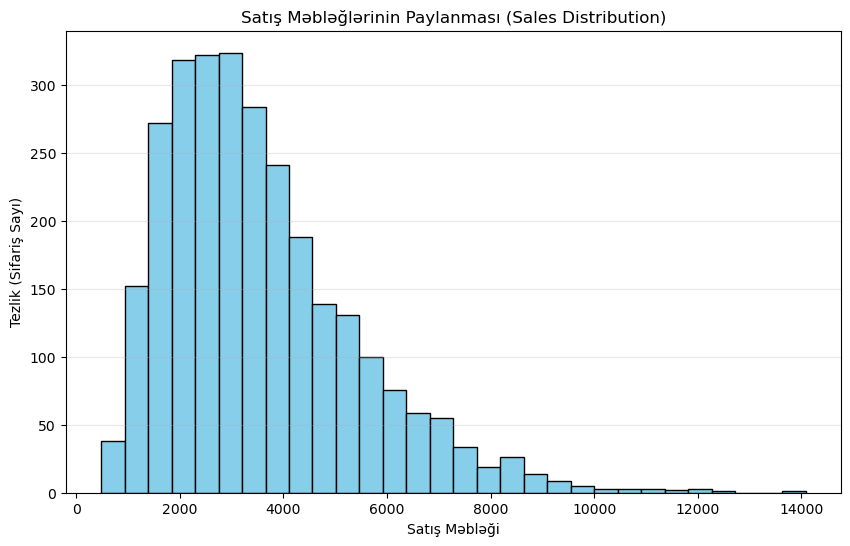

In [23]:
plt.figure(figsize=(10, 6))
plt.hist(df['SALES'], bins=30, color='skyblue', edgecolor='black')
plt.title('Satış Məbləğlərinin Paylanması (Sales Distribution)')
plt.xlabel('Satış Məbləği')
plt.ylabel('Tezlik (Sifariş Sayı)')
plt.grid(axis='y', alpha=0.3)
plt.show()

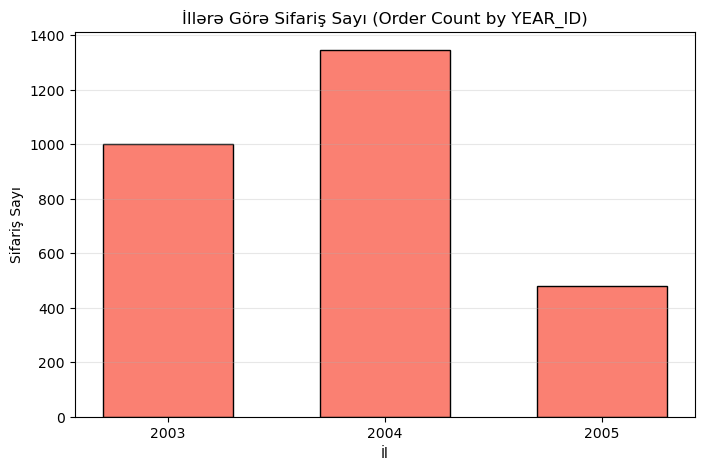

In [24]:
plt.figure(figsize=(8, 5))
year_counts = df['YEAR_ID'].value_counts().sort_index()
plt.bar(year_counts.index.astype(str), year_counts.values, color='salmon', edgecolor='black', width=0.6)
plt.title('İllərə Görə Sifariş Sayı (Order Count by YEAR_ID)')
plt.xlabel('İl')
plt.ylabel('Sifariş Sayı')
plt.grid(axis='y', alpha=0.3)
plt.show()